In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"D:\Desktop\PANDAS\Project\marking_ab\marketing_AB.csv")

# Display first 5 rows
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [3]:
# Shape of dataset
rows, columns = df.shape

print("Rows :", rows)
print("Columns :", columns)

Rows : 588101
Columns : 7


In [4]:
(rows, columns)

(588101, 7)

In [5]:
# Display all columns with their data types
df.dtypes


Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [6]:
# Create a DataFrame for better readability
column_info = pd.DataFrame({
    "Column Name": df.columns,
    "Data Type": df.dtypes.values
})

column_info

,Column Name,Data Type
0,Unnamed: 0,int64
1,user id,int64
2,test group,object
3,converted,bool
4,total ads,int64
5,most ads day,object
6,most ads hour,int64


In [7]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
['Unnamed: 0', 'user id', 'total ads', 'most ads hour']


In [8]:
numerical_columns = df.select_dtypes(include='number')

numerical_columns.head()

,Unnamed: 0,user id,total ads,most ads hour
0,0,1069124,130,20
1,1,1119715,93,22
2,2,1144181,21,18
3,3,1435133,355,10
4,4,1015700,276,14


In [9]:
df.isnull().sum()

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [10]:
df.describe()

,Unnamed: 0,user id,total ads,most ads hour
count,588101.000000,5.881010e+05,588101.000000,588101.000000
mean,294050.000000,1.310692e+06,24.820876,14.469061
std,169770.279667,2.022260e+05,43.715181,4.834634
min,0.000000,9.000000e+05,1.000000,0.000000
25%,147025.000000,1.143190e+06,4.000000,11.000000
50%,294050.000000,1.313725e+06,13.000000,14.000000
75%,441075.000000,1.484088e+06,27.000000,18.000000
max,588100.000000,1.654483e+06,2065.000000,23.000000


In [11]:
# Which columns are binary?
# Identify binary columns
binary_columns = []

for col in df.columns:
    if df[col].nunique() == 2:
        binary_columns.append(col)

print("Binary Columns:")
print(binary_columns)

Binary Columns:
['test group', 'converted']


In [12]:
pd.DataFrame({
    "Binary Columns": binary_columns
})

,Binary Columns
0,test group
1,converted


A binary column contains only two unique values, such as:

Yes / No
True / False
0 / 1
Control / Treatment

Binary variables are extremely important in A/B testing because they often represent outcomes or experiment groups.

In [13]:
# Select datetime columns
datetime_columns = df.select_dtypes(include=['datetime64[ns]']).columns.tolist()

print("Datetime Columns:")
print(datetime_columns)

Datetime Columns:
[]


In [14]:
# Example: Convert a date column to datetime
# df['date'] = pd.to_datetime(df['date'])

df.dtypes

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [15]:
# Identify text columns (object type excluding binary/categorical if needed)
text_columns = df.select_dtypes(include=['object']).columns.tolist()

print("Text Columns:")
print(text_columns)

Text Columns:
['test group', 'most ads day']


In [16]:
text_df = pd.DataFrame({
    "Text Columns": text_columns
})

text_df

,Text Columns
0,test group
1,most ads day


In [17]:
print(df.columns.tolist())

['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']


In [18]:
# Check unique values in each column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique()[:10])   # Display first 10 unique values


Column: Unnamed: 0
[0 1 2 3 4 5 6 7 8 9]

Column: user id
[1069124 1119715 1144181 1435133 1015700 1137664 1116205 1496843 1448851
 1446284]

Column: test group
['ad' 'psa']

Column: converted
[False  True]

Column: total ads
[130  93  21 355 276 734 264  17 142 209]

Column: most ads day
['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']

Column: most ads hour
[20 22 18 10 14 13 19 11 12 16]


In [19]:
# Find columns with only two unique values
binary_columns = []

for col in df.columns:
    if df[col].nunique() == 2:
        binary_columns.append(col)

print("Possible Target Variables:")
print(binary_columns)

Possible Target Variables:
['test group', 'converted']


In [20]:
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")

Unnamed: 0: 588101 unique values
user id: 588101 unique values
test group: 2 unique values
converted: 2 unique values
total ads: 807 unique values
most ads day: 7 unique values
most ads hour: 24 unique values


In [21]:
# Check for Unique Identifier
for col in df.columns:
    if df[col].nunique() == len(df):
        print(f"{col} is a unique identifier.")

Unnamed: 0 is a unique identifier.
user id is a unique identifier.


In [22]:
# Check if 'user id' exists and is unique
if 'user id' in df.columns:
    print(df['user id'].is_unique)

True


In [23]:
# Display all columns
df.columns

Index(['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads',
       'most ads day', 'most ads hour'],
      dtype='object')

In [24]:
# Display all columns for manual categorization
print(df.columns.tolist())

['Unnamed: 0', 'user id', 'test group', 'converted', 'total ads', 'most ads day', 'most ads hour']


### 1) How many missing values are present in the dataset? Which columns contain missing values? What percentage of data is missing? What should be done?

In [25]:
# Count missing values in each column
missing_values = df.isnull().sum()

missing_values

Unnamed: 0       0
user id          0
test group       0
converted        0
total ads        0
most ads day     0
most ads hour    0
dtype: int64

In [26]:
# Calculate percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

Unnamed: 0       0.0
user id          0.0
test group       0.0
converted        0.0
total ads        0.0
most ads day     0.0
most ads hour    0.0
dtype: float64

In [27]:
missing_report = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": round((df.isnull().sum()/len(df))*100,2)
})

missing_report

,Missing Values,Missing Percentage
Unnamed: 0,0,0.0
user id,0,0.0
test group,0,0.0
converted,0,0.0
total ads,0,0.0
most ads day,0,0.0
most ads hour,0,0.0


In [28]:
# Display Only Columns with Missing Values
missing_report[missing_report["Missing Values"]>0]

,Missing Values,Missing Percentage


### Are there duplicate rows?

In [29]:
# Count duplicate rows
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [30]:
df[df.duplicated()]

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour


In [31]:
df = df.drop_duplicates()

### Are duplicate IDs present?

In [32]:
duplicate_ids = df["user id"].duplicated().sum()

print("Duplicate User IDs:", duplicate_ids)

Duplicate User IDs: 0


In [33]:
df[df["user id"].duplicated(keep=False)].sort_values("user id")

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour


### Are there outliers in numerical columns? Which columns contain them? What is their business impact?

In [34]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

numerical_columns

Index(['Unnamed: 0', 'user id', 'total ads', 'most ads hour'], dtype='object')

In [35]:
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

Unnamed: 0: 0 outliers
user id: 0 outliers
total ads: 52057 outliers
most ads hour: 5536 outliers


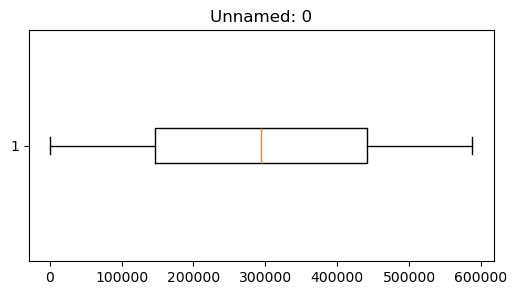

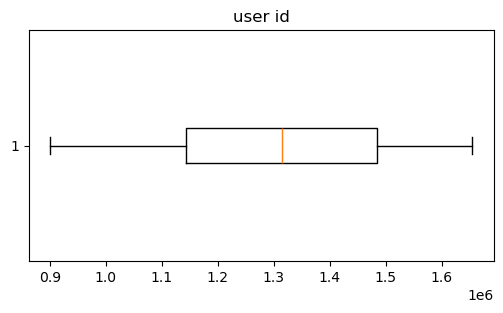

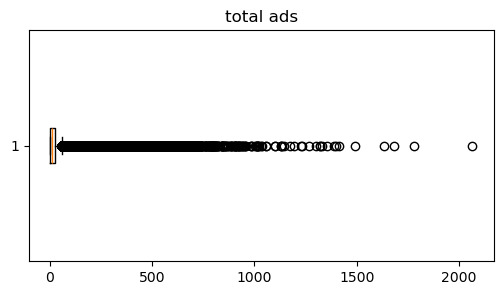

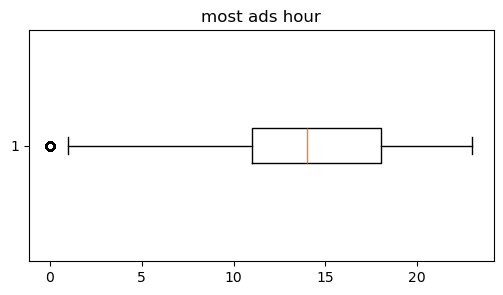

In [36]:
for col in numerical_columns:
    plt.figure(figsize=(6,3))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

### Are there any invalid values in the dataset?

In [37]:
# Step 1: Check Unique Values for Each Column
for col in df.columns:
    print(f"\nColumn: {col}")
    print(df[col].unique())


Column: Unnamed: 0
[     0      1      2 ... 588098 588099 588100]

Column: user id
[1069124 1119715 1144181 ... 1038442 1496395 1237779]

Column: test group
['ad' 'psa']

Column: converted
[False  True]

Column: total ads
[ 130   93   21  355  276  734  264   17  142  209   47   61   40   20
    9   64   26  248   73  281  389  136   87   46    3  114  175  119
  313   89  364   24  112   49   27  274   45  177   90  265   71   31
  588   56  108  103  239   63   66  111   74   14  258 1057  137  131
  124   13   37  738  199  211   98   19  127   18  126  197   77   60
   95   97   22  117   41   57  593   28   85   53   43  133   33 1328
    7    6   62  247  464   99  233  139  407  323   76  395  166   34
  246  653  122   32  386   44  138  109   39  159   30   59  421  446
  555  105  128  310  163   10  290  164   79  312   16  161  505  640
  118  266  456   80  100  983   36    1    5  463  720   52  442  334
 1056  270  240  194  271  489  115  180  241   15  154  120   29 

In [38]:
# Step 2: Check Invalid Values in Binary Columns
# Example for converted column
print(df["converted"].value_counts())

# Example for test group
print(df["test group"].value_counts())

converted
False    573258
True      14843
Name: count, dtype: int64
test group
ad     564577
psa     23524
Name: count, dtype: int64


In [39]:
# Step 3: Check Numerical Columns for Invalid Values
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for col in numerical_columns:
    print(f"\n{col}")
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())


Unnamed: 0
Minimum: 0
Maximum: 588100

user id
Minimum: 900000
Maximum: 1654483

total ads
Minimum: 1
Maximum: 2065

most ads hour
Minimum: 0
Maximum: 23


### Are there negative values? Are they valid or invalid?

In [40]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    negative_count = (df[col] < 0).sum()
    print(f"{col}: {negative_count}")

Unnamed: 0: 0
user id: 0
total ads: 0
most ads hour: 0


In [41]:
# Show Negative Records

In [42]:
for col in numerical_columns:
    print(f"\nNegative values in {col}")
    print(df[df[col] < 0])


Negative values in Unnamed: 0
Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []

Negative values in user id
Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []

Negative values in total ads
Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []

Negative values in most ads hour
Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []


# Are there impossible values in the dataset?

In [43]:
# Check Hour Column
if "most ads hour" in df.columns:
    print(df[(df["most ads hour"] < 0) | (df["most ads hour"] > 23)])

Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []


In [44]:
# Check Total Ads
if "total ads" in df.columns:
    print(df[df["total ads"] < 0])

Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []


In [45]:
# Check Days
valid_days = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

if "most ads day" in df.columns:
    invalid_days = df[~df["most ads day"].isin(valid_days)]
    print(invalid_days)

Empty DataFrame
Columns: [Unnamed: 0, user id, test group, converted, total ads, most ads day, most ads hour]
Index: []


### Are there data inconsistencies?

In [46]:
text_columns = df.select_dtypes(include=["object"]).columns

for col in text_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


test group
test group
ad     564577
psa     23524
Name: count, dtype: int64

most ads day
most ads day
Friday       92608
Monday       87073
Sunday       85391
Thursday     82982
Saturday     81660
Wednesday    80908
Tuesday      77479
Name: count, dtype: int64


In [47]:
## Detect Leading/Trailing Spaces
for col in text_columns:
    inconsistent = df[df[col] != df[col].str.strip()]
    print(f"{col}: {len(inconsistent)} inconsistent records")


test group: 0 inconsistent records
most ads day: 0 inconsistent records


In [48]:
# Standardize Text
for col in text_columns:
    df[col] = df[col].str.strip().str.lower()


### Are there any incorrect data types? If yes, what should they be?

In [49]:
# Display current data types
df.dtypes

Unnamed: 0        int64
user id           int64
test group       object
converted          bool
total ads         int64
most ads day     object
most ads hour     int64
dtype: object

In [50]:
datatype_report = pd.DataFrame({
    "Column": df.columns,
    "Current Data Type": df.dtypes.values
})

datatype_report

,Column,Current Data Type
0,Unnamed: 0,int64
1,user id,int64
2,test group,object
3,converted,bool
4,total ads,int64
5,most ads day,object
6,most ads hour,int64


### Are there leading or trailing spaces in text columns? How should they be cleaned?

In [51]:
text_columns = df.select_dtypes(include="object").columns

text_columns

Index(['test group', 'most ads day'], dtype='object')

In [52]:
for col in text_columns:
    count = (df[col] != df[col].str.strip()).sum()
    print(f"{col}: {count} rows contain extra spaces")

test group: 0 rows contain extra spaces
most ads day: 0 rows contain extra spaces


In [53]:
for col in text_columns:
    df[col] = df[col].str.strip()

In [54]:
for col in text_columns:
    count = (df[col] != df[col].str.strip()).sum()
    print(f"{col}: {count}")

test group: 0
most ads day: 0


In [55]:
# Which columns have high cardinality? What is their impact on analysis?
# Count unique values in each column
cardinality = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values,
    "Unique Percentage": round((df.nunique() / len(df)) * 100, 2).values
})

cardinality.sort_values(by="Unique Values", ascending=False)

,Column,Unique Values,Unique Percentage
0,Unnamed: 0,588101,100.00
1,user id,588101,100.00
4,total ads,807,0.14
6,most ads hour,24,0.00
5,most ads day,7,0.00
2,test group,2,0.00
3,converted,2,0.00


In [56]:
# Columns with more than 100 unique values
high_cardinality = cardinality[cardinality["Unique Values"] > 100]

high_cardinality

,Column,Unique Values,Unique Percentage
0,Unnamed: 0,588101,100.00
1,user id,588101,100.00
4,total ads,807,0.14


### Which numerical variables are skewed? What transformations are recommended?

In [57]:
# Calculate skewness for numerical columns
skewness = df.select_dtypes(include=['int64', 'float64']) \
             .skew() \
             .sort_values(ascending=False)

skewness

total ads        7.433113e+00
Unnamed: 0      -2.049688e-16
user id         -1.003578e-01
most ads hour   -3.369716e-01
dtype: float64

In [58]:
skew_report = pd.DataFrame({
    "Column": skewness.index,
    "Skewness": skewness.values
})

skew_report

,Column,Skewness
0,total ads,7.433113e+00
1,Unnamed: 0,-2.049688e-16
2,user id,-1.003578e-01
3,most ads hour,-3.369716e-01


### Histogram

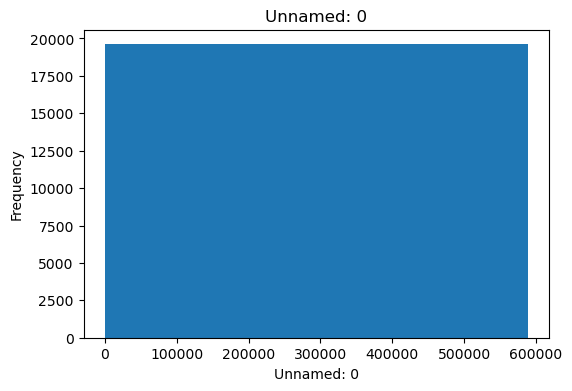

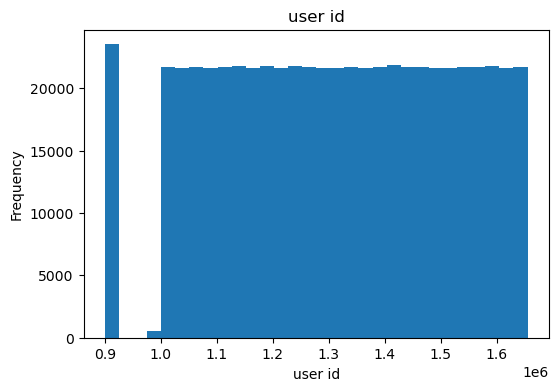

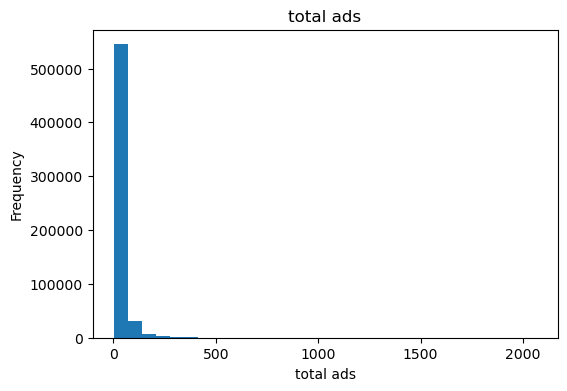

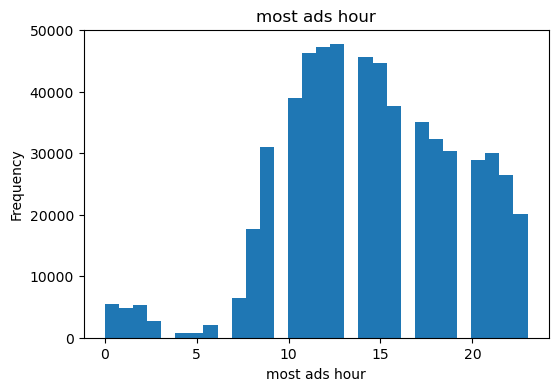

In [59]:
import matplotlib.pyplot as plt

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# Is the dataset imbalanced? What is the overall Data Quality Score?

In [60]:
df["converted"].value_counts()

converted
False    573258
True      14843
Name: count, dtype: int64

In [61]:
round(
    df["converted"].value_counts(normalize=True) * 100,
    2
)

converted
False    97.48
True      2.52
Name: proportion, dtype: float64

### plot distribution

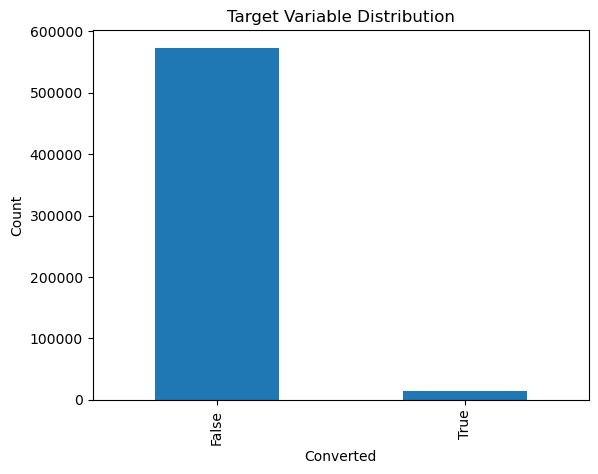

In [62]:
import matplotlib.pyplot as plt

df["converted"].value_counts().plot(
    kind="bar"
)

plt.title("Target Variable Distribution")
plt.xlabel("Converted")
plt.ylabel("Count")
plt.show()

## Exploratory Data Analysis (EDA)

### What is the overall summary of the dataset?

In [63]:
df = df.drop('Unnamed: 0',axis = 1)

In [64]:
# Basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 588101 entries, 0 to 588100
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   user id        588101 non-null  int64 
 1   test group     588101 non-null  object
 2   converted      588101 non-null  bool  
 3   total ads      588101 non-null  int64 
 4   most ads day   588101 non-null  object
 5   most ads hour  588101 non-null  int64 
dtypes: bool(1), int64(3), object(2)
memory usage: 23.0+ MB


In [65]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 588101
Number of Columns: 6


In [66]:
df.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,monday,20
1,1119715,ad,False,93,tuesday,22
2,1144181,ad,False,21,tuesday,18
3,1435133,ad,False,355,tuesday,10
4,1015700,ad,False,276,friday,14


In [67]:
df.tail()

,user id,test group,converted,total ads,most ads day,most ads hour
588096,1278437,ad,False,1,tuesday,23
588097,1327975,ad,False,1,tuesday,23
588098,1038442,ad,False,3,tuesday,23
588099,1496395,ad,False,1,tuesday,23
588100,1237779,ad,False,1,tuesday,23


# Random Sample

In [68]:
df.sample(5, random_state=42)

,user id,test group,converted,total ads,most ads day,most ads hour
127183,1207161,ad,False,16,monday,10
310440,1580888,ad,False,19,sunday,13
260659,1224574,ad,False,19,tuesday,15
313,1491238,ad,False,68,sunday,21
135803,1506043,ad,False,2,thursday,22


## What are the descriptive statistics of the numerical variables?

In [69]:
df.describe()

,user id,total ads,most ads hour
count,5.881010e+05,588101.000000,588101.000000
mean,1.310692e+06,24.820876,14.469061
std,2.022260e+05,43.715181,4.834634
min,9.000000e+05,1.000000,0.000000
25%,1.143190e+06,4.000000,11.000000
50%,1.313725e+06,13.000000,14.000000
75%,1.484088e+06,27.000000,18.000000
max,1.654483e+06,2065.000000,23.000000


In [70]:
df.describe(include='all')

,user id,test group,converted,total ads,most ads day,most ads hour
count,5.881010e+05,588101,588101,588101.000000,588101,588101.000000
unique,NaN,2,2,NaN,7,NaN
top,NaN,ad,False,NaN,friday,NaN
freq,NaN,564577,573258,NaN,92608,NaN
mean,1.310692e+06,NaN,NaN,24.820876,NaN,14.469061
std,2.022260e+05,NaN,NaN,43.715181,NaN,4.834634
min,9.000000e+05,NaN,NaN,1.000000,NaN,0.000000
25%,1.143190e+06,NaN,NaN,4.000000,NaN,11.000000
50%,1.313725e+06,NaN,NaN,13.000000,NaN,14.000000
75%,1.484088e+06,NaN,NaN,27.000000,NaN,18.000000


In [71]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
user id,588101.0,1.310692e+06,202225.983128,900000.0,1143190.0,1313725.0,1484088.0,1654483.0
total ads,588101.0,2.482088e+01,43.715181,1.0,4.0,13.0,27.0,2065.0
most ads hour,588101.0,1.446906e+01,4.834634,0.0,11.0,14.0,18.0,23.0


## How are the numerical variables distributed?

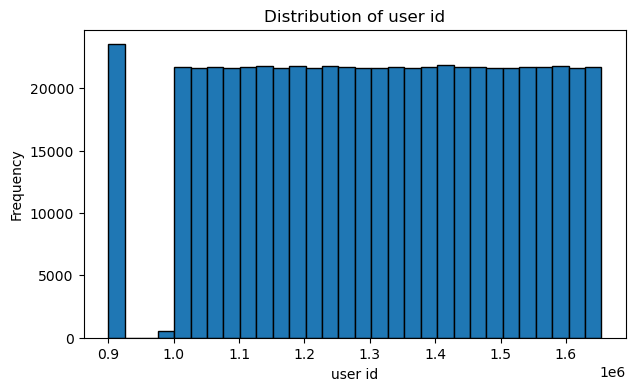

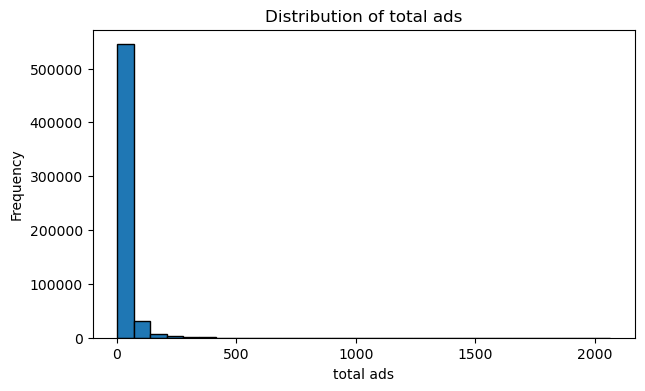

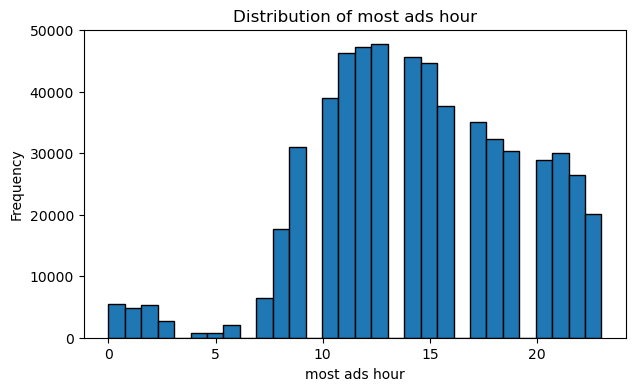

In [72]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    plt.figure(figsize=(7,4))
    plt.hist(df[col], bins=30, edgecolor='black')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

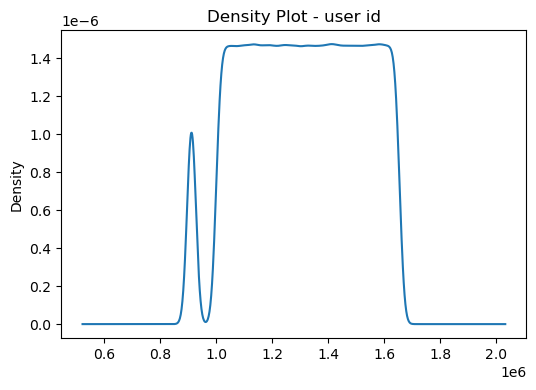

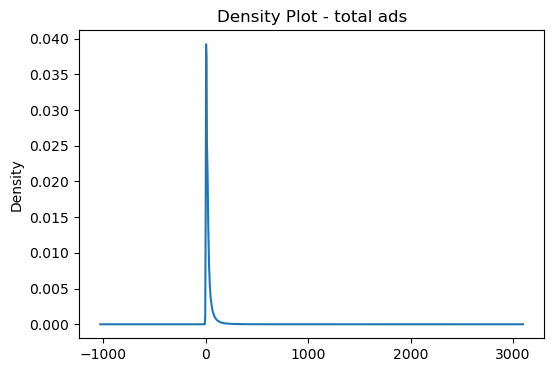

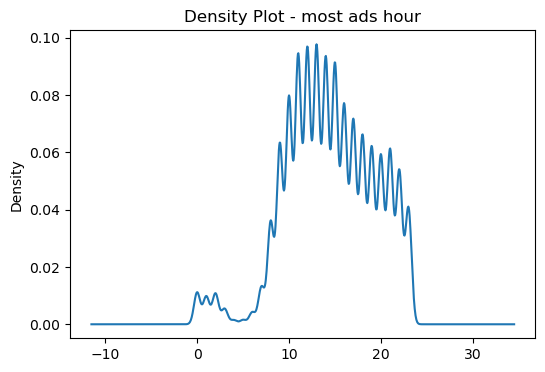

In [73]:
for col in numerical_columns:
    df[col].plot(kind='density', figsize=(6,4), title=f"Density Plot - {col}")
    plt.show()

## What is the frequency distribution of categorical variables?

In [74]:
## Frequency Counts
categorical_columns = df.select_dtypes(include=['object', 'category', 'bool']).columns

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


test group
test group
ad     564577
psa     23524
Name: count, dtype: int64

converted
converted
False    573258
True      14843
Name: count, dtype: int64

most ads day
most ads day
friday       92608
monday       87073
sunday       85391
thursday     82982
saturday     81660
wednesday    80908
tuesday      77479
Name: count, dtype: int64


In [75]:
## Percentage Distribution

for col in categorical_columns:
    print(f"\nPercentage Distribution - {col}")
    print(round(df[col].value_counts(normalize=True) * 100, 2))


Percentage Distribution - test group
test group
ad     96.0
psa     4.0
Name: proportion, dtype: float64

Percentage Distribution - converted
converted
False    97.48
True      2.52
Name: proportion, dtype: float64

Percentage Distribution - most ads day
most ads day
friday       15.75
monday       14.81
sunday       14.52
thursday     14.11
saturday     13.89
wednesday    13.76
tuesday      13.17
Name: proportion, dtype: float64


In [76]:
# Bar Charts

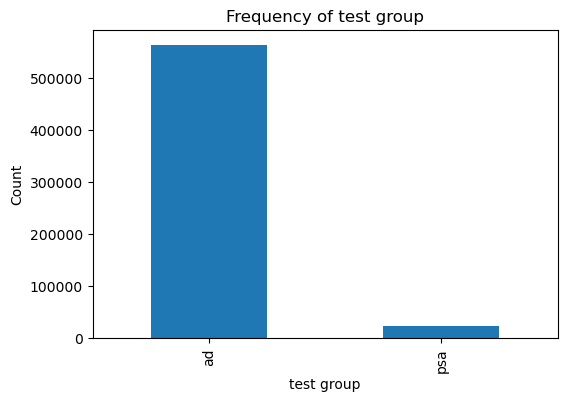

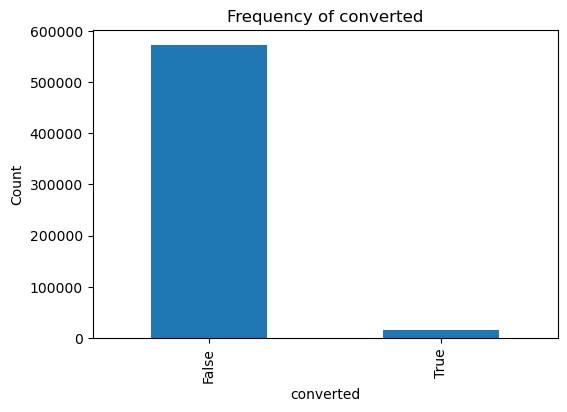

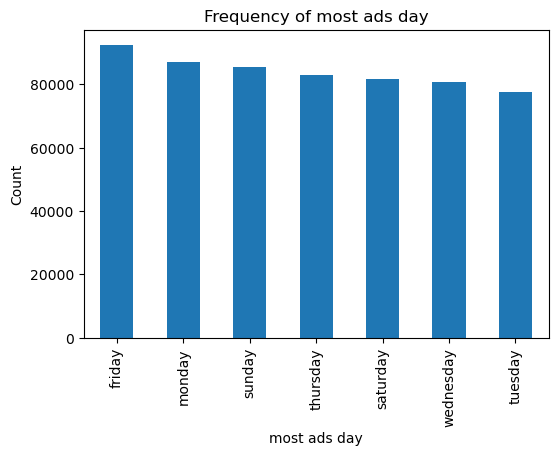

In [77]:
for col in categorical_columns:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## Is there a relationship between numerical variables? (Correlation Analysis)

## Correlation Matrix

In [78]:
# Calculate correlation matrix
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,user id,converted,total ads,most ads hour
user id,1.000000,0.000635,0.012336,-0.023002
converted,0.000635,1.000000,0.217419,0.019674
total ads,0.012336,0.217419,1.000000,-0.010837
most ads hour,-0.023002,0.019674,-0.010837,1.000000


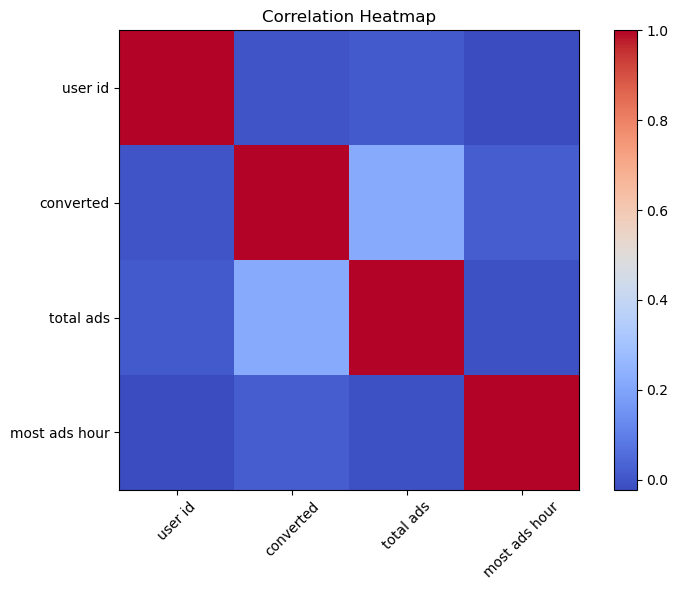

In [79]:
plt.figure(figsize=(8,6))

plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")

plt.colorbar()

plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45)

plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [80]:
correlation_matrix.unstack().sort_values(ascending=False)

user id        user id          1.000000
converted      converted        1.000000
most ads hour  most ads hour    1.000000
total ads      total ads        1.000000
converted      total ads        0.217419
total ads      converted        0.217419
most ads hour  converted        0.019674
converted      most ads hour    0.019674
total ads      user id          0.012336
user id        total ads        0.012336
               converted        0.000635
converted      user id          0.000635
most ads hour  total ads       -0.010837
total ads      most ads hour   -0.010837
user id        most ads hour   -0.023002
most ads hour  user id         -0.023002
dtype: float64

# Perform Univariate Analysis


Summary of user id
count    5.881010e+05
mean     1.310692e+06
std      2.022260e+05
min      9.000000e+05
25%      1.143190e+06
50%      1.313725e+06
75%      1.484088e+06
max      1.654483e+06
Name: user id, dtype: float64


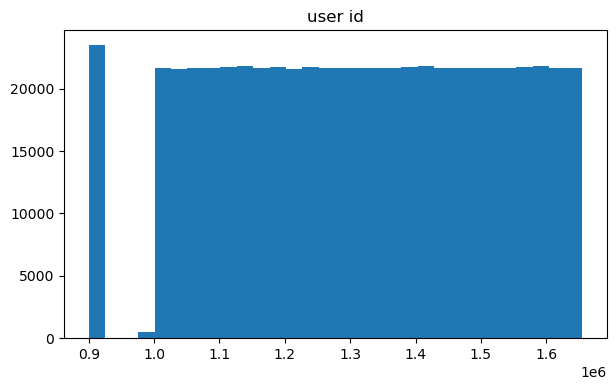


Summary of total ads
count    588101.000000
mean         24.820876
std          43.715181
min           1.000000
25%           4.000000
50%          13.000000
75%          27.000000
max        2065.000000
Name: total ads, dtype: float64


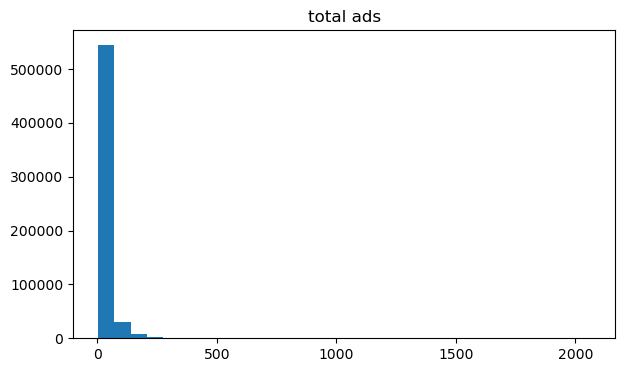


Summary of most ads hour
count    588101.000000
mean         14.469061
std           4.834634
min           0.000000
25%          11.000000
50%          14.000000
75%          18.000000
max          23.000000
Name: most ads hour, dtype: float64


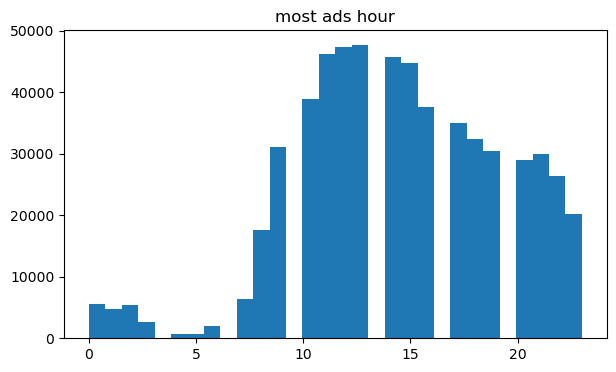

In [81]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_columns:

    print(f"\nSummary of {col}")

    print(df[col].describe())

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.show()

test group
ad     564577
psa     23524
Name: count, dtype: int64


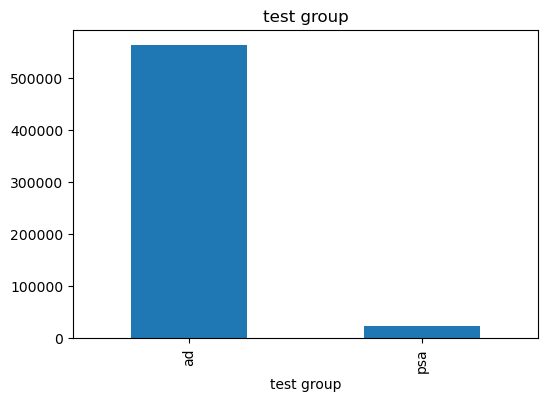

converted
False    573258
True      14843
Name: count, dtype: int64


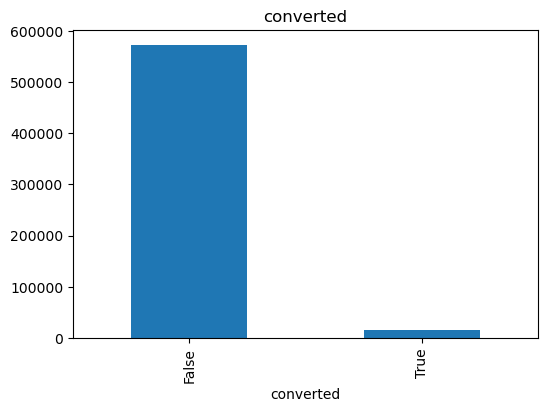

most ads day
friday       92608
monday       87073
sunday       85391
thursday     82982
saturday     81660
wednesday    80908
tuesday      77479
Name: count, dtype: int64


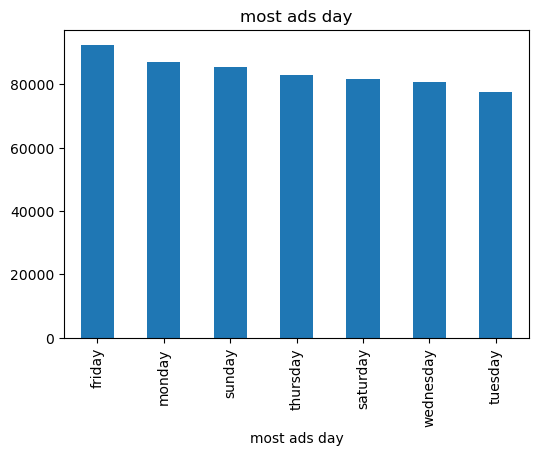

In [82]:
categorical_columns = df.select_dtypes(include=['object','category','bool']).columns

for col in categorical_columns:

    print(df[col].value_counts())

    plt.figure(figsize=(6,4))

    df[col].value_counts().plot(kind="bar")

    plt.title(col)

    plt.show()

# Total Ads vs Conversion

In [83]:
conversion_ads = df.groupby("converted")["total ads"].mean()

conversion_ads

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

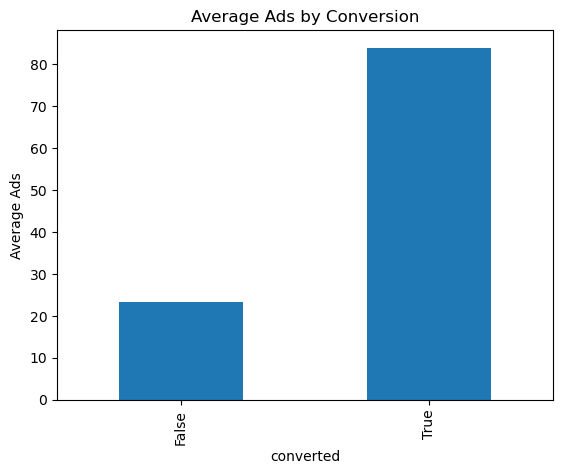

In [84]:
conversion_ads.plot(kind="bar")

plt.title("Average Ads by Conversion")

plt.ylabel("Average Ads")

plt.show()

In [85]:
pd.crosstab(df["test group"], df["converted"])

converted,False,True
test group,,
ad,550154,14423
psa,23104,420


In [86]:
pd.crosstab(
    df["test group"],
    df["converted"],
    normalize="index"
)*100

converted,False,True
test group,,
ad,97.445344,2.554656
psa,98.214589,1.785411


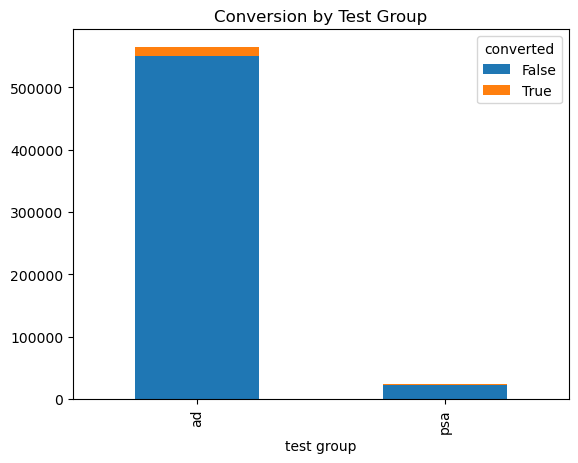

In [87]:
pd.crosstab(df["test group"],df["converted"]).plot(kind="bar",stacked=True)

plt.title("Conversion by Test Group")

plt.show()

In [88]:
day_conversion = pd.crosstab(
    df["most ads day"],
    df["converted"],
    normalize="index"
)*100

day_conversion

converted,False,True
most ads day,,
friday,97.778810,2.221190
monday,96.718845,3.281155
saturday,97.894930,2.105070
sunday,97.552435,2.447565
thursday,97.842906,2.157094
tuesday,97.015966,2.984034
wednesday,97.505809,2.494191


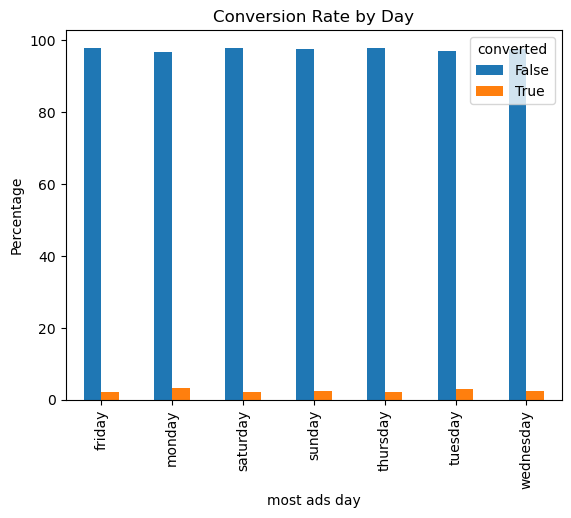

In [89]:
day_conversion.plot(kind="bar")

plt.title("Conversion Rate by Day")

plt.ylabel("Percentage")

plt.show()

## Perform Multivariate Analysis

## Average Ads by Test Group and Conversion

In [90]:
multi_analysis = df.groupby(
    ["test group","converted"]
)["total ads"].mean()

multi_analysis

test group  converted
ad          False        23.274449
            True         83.905567
psa         False        23.697412
            True         83.276190
Name: total ads, dtype: float64

In [91]:
pivot = pd.pivot_table(

    df,

    values="total ads",

    index="most ads day",

    columns="test group",

    aggfunc="mean"

)

pivot

test group,ad,psa
most ads day,,
friday,26.682574,24.967131
monday,25.389764,23.866933
saturday,25.126812,28.008397
sunday,24.369140,25.332788
thursday,23.267613,26.693982
tuesday,24.030883,21.221190
wednesday,24.605906,23.059599


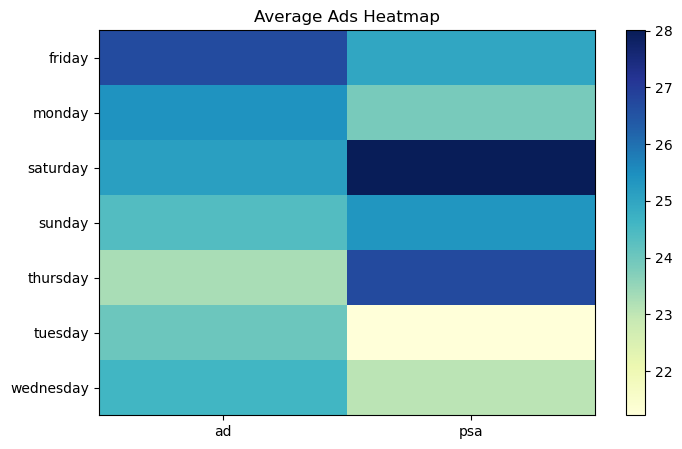

In [92]:
plt.figure(figsize=(8,5))

plt.imshow(pivot, cmap="YlGnBu", aspect="auto")

plt.colorbar()

plt.xticks(range(len(pivot.columns)), pivot.columns)

plt.yticks(range(len(pivot.index)), pivot.index)

plt.title("Average Ads Heatmap")

plt.show()

# Analyze Customer Behavior

## Customer Conversion Behavior

In [93]:
# Conversion count
customer_behavior = df["converted"].value_counts()

customer_behavior

converted
False    573258
True      14843
Name: count, dtype: int64

In [94]:
conversion_percentage = round(
    df["converted"].value_counts(normalize=True)*100,
    2
)

conversion_percentage

converted
False    97.48
True      2.52
Name: proportion, dtype: float64

In [95]:
# Average Ads Seen by Customer Type

In [96]:
customer_ads = df.groupby("converted")["total ads"].agg(
    ["count","mean","median","min","max"]
)

customer_ads

,count,mean,median,min,max
converted,,,,,
False,573258,23.291495,13.0,1,2065
True,14843,83.887759,64.0,1,1778


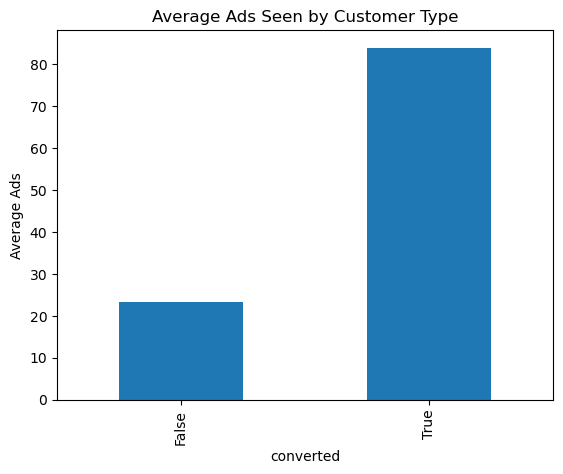

In [97]:
import matplotlib.pyplot as plt

customer_ads["mean"].plot(kind="bar")

plt.title("Average Ads Seen by Customer Type")
plt.ylabel("Average Ads")
plt.show()

## Analyze Campaign Performance

In [98]:
campaign_summary = df.groupby("test group").agg({

    "converted":"sum",

    "user id":"count",

    "total ads":"mean"

})

campaign_summary.rename(columns={

    "user id":"Total Users",

    "converted":"Conversions",

    "total ads":"Average Ads"

}, inplace=True)

campaign_summary

,Conversions,Total Users,Average Ads
test group,,,
ad,14423,564577,24.823365
psa,420,23524,24.761138


In [99]:
campaign_summary["Conversion Rate (%)"] = round(

campaign_summary["Conversions"]/

campaign_summary["Total Users"]*100,

2)

campaign_summary

,Conversions,Total Users,Average Ads,Conversion Rate (%)
test group,,,,
ad,14423,564577,24.823365,2.55
psa,420,23524,24.761138,1.79


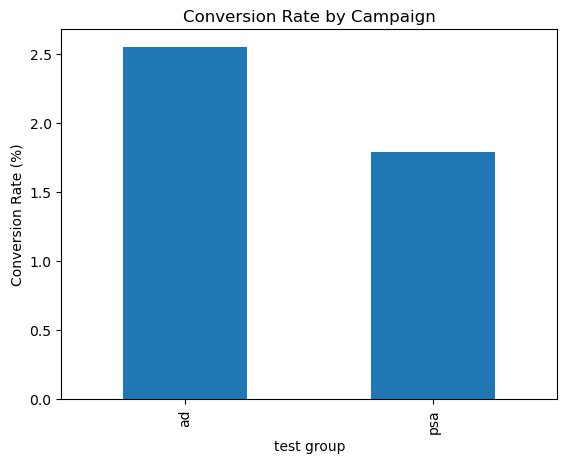

In [100]:
campaign_summary["Conversion Rate (%)"].plot(

kind="bar"

)

plt.title("Conversion Rate by Campaign")

plt.ylabel("Conversion Rate (%)")

plt.show()

### Analyze Revenue Trends

In [101]:
if "revenue" in df.columns:

    revenue_trend = df.groupby("date")["revenue"].sum()

    revenue_trend.plot(figsize=(10,5))

    plt.title("Revenue Trend")

    plt.show()

else:

    print("Revenue column not available.")

Revenue column not available.


## Analyze Conversion

In [102]:
conversion_rate = round(

df["converted"].mean()*100,

2)

print(conversion_rate)

2.52


In [103]:
campaign_conversion = pd.crosstab(

df["test group"],

df["converted"],

normalize="index"

)*100

campaign_conversion

converted,False,True
test group,,
ad,97.445344,2.554656
psa,98.214589,1.785411


In [104]:
day_conversion = pd.crosstab(

df["most ads day"],

df["converted"],

normalize="index"

)*100

day_conversion

converted,False,True
most ads day,,
friday,97.778810,2.221190
monday,96.718845,3.281155
saturday,97.894930,2.105070
sunday,97.552435,2.447565
thursday,97.842906,2.157094
tuesday,97.015966,2.984034
wednesday,97.505809,2.494191


In [105]:
hour_conversion = pd.crosstab(

df["most ads hour"],

df["converted"],

normalize="index"

)*100

hour_conversion

converted,False,True
most ads hour,,
0,98.157514,1.842486
1,98.708871,1.291129
2,99.268704,0.731296
3,98.954834,1.045166
4,98.476454,1.523546
5,97.908497,2.091503
6,97.775629,2.224371
7,98.188915,1.811085
8,98.048448,1.951552


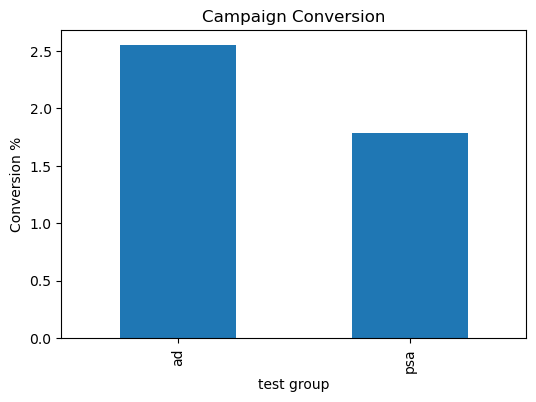

In [106]:
campaign_conversion[True].plot(

kind="bar",

figsize=(6,4)

)

plt.ylabel("Conversion %")

plt.title("Campaign Conversion")

plt.show()

## Evaluate Overall Business Performance

In [107]:
business_summary = {

"Total Customers": len(df),

"Converted Customers": df["converted"].sum(),

"Conversion Rate": round(df["converted"].mean()*100,2),

"Average Ads": round(df["total ads"].mean(),2)

}

business_summary

{'Total Customers': 588101,
 'Converted Customers': np.int64(14843),
 'Conversion Rate': np.float64(2.52),
 'Average Ads': np.float64(24.82)}

### Analyze Time-Series Trends

In [108]:
if "date" in df.columns:

    daily = df.groupby("date")["converted"].mean()

    daily.plot(figsize=(10,5))

    plt.title("Daily Conversion Trend")

    plt.show()

else:

    print("Time-series analysis cannot be performed because the dataset does not contain a date column.")

Time-series analysis cannot be performed because the dataset does not contain a date column.


## How is the customer distribution across the A/B test groups?

# Determine whether the experiment is properly balanced between the Ad and PSA groups.

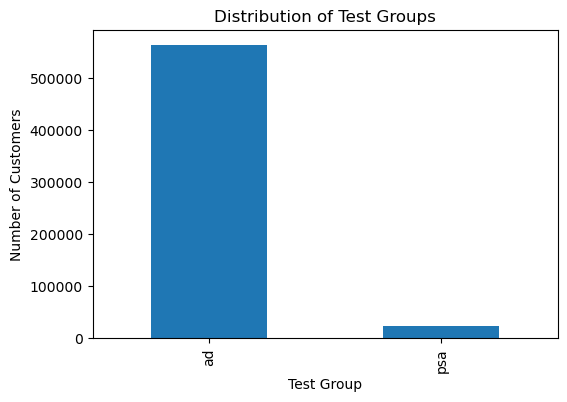

In [109]:
import matplotlib.pyplot as plt

df["test group"].value_counts().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Distribution of Test Groups")
plt.xlabel("Test Group")
plt.ylabel("Number of Customers")
plt.show()

# What is the overall conversion rate?

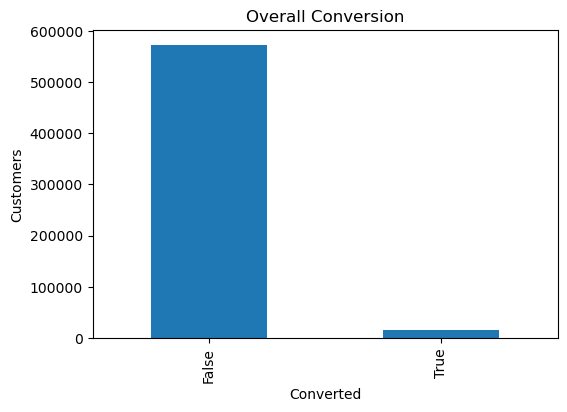

In [110]:
conversion = df["converted"].value_counts()

conversion.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Overall Conversion")
plt.xlabel("Converted")
plt.ylabel("Customers")
plt.show()

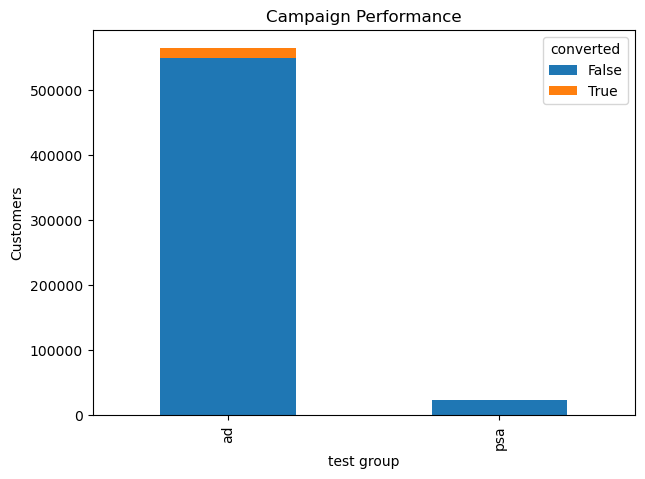

In [111]:
pd.crosstab(
    df["test group"],
    df["converted"]
).plot(
    kind="bar",
    stacked=True,
    figsize=(7,5)
)

plt.title("Campaign Performance")
plt.ylabel("Customers")
plt.show()

## How many advertisements do customers usually see?

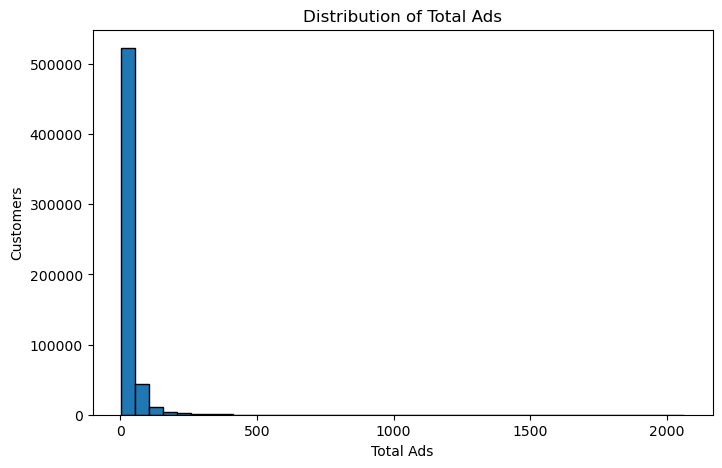

In [112]:
plt.figure(figsize=(8,5))

plt.hist(
    df["total ads"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribution of Total Ads")
plt.xlabel("Total Ads")
plt.ylabel("Customers")

plt.show()

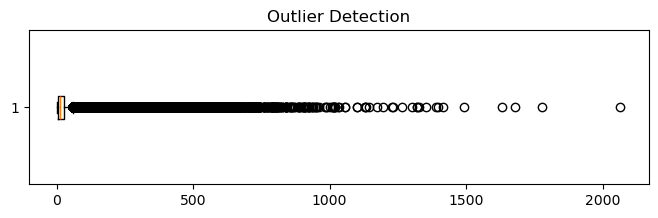

In [113]:
plt.figure(figsize=(8,2))

plt.boxplot(df["total ads"], vert=False)

plt.title("Outlier Detection")

plt.show()

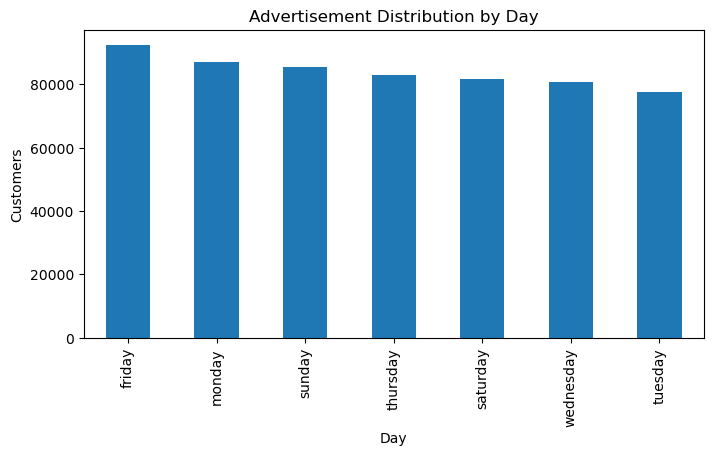

In [114]:
df["most ads day"].value_counts().plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Advertisement Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Customers")

plt.show()

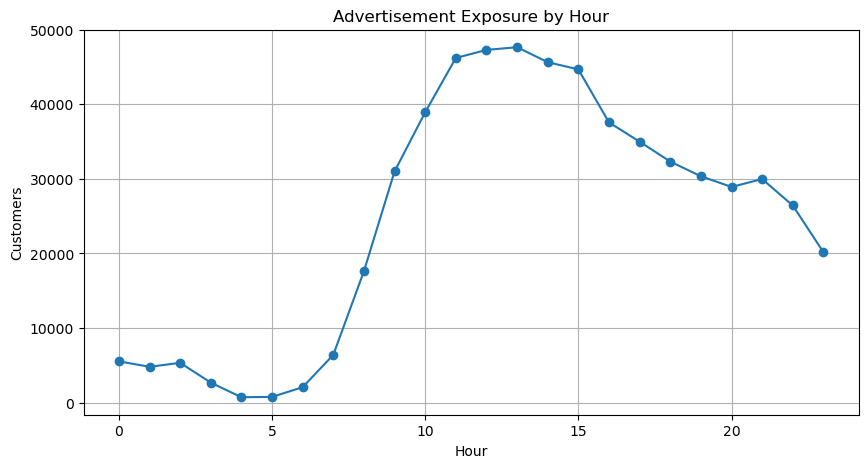

In [115]:
hour = df["most ads hour"].value_counts().sort_index()

hour.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Advertisement Exposure by Hour")
plt.xlabel("Hour")
plt.ylabel("Customers")

plt.grid(True)

plt.show()

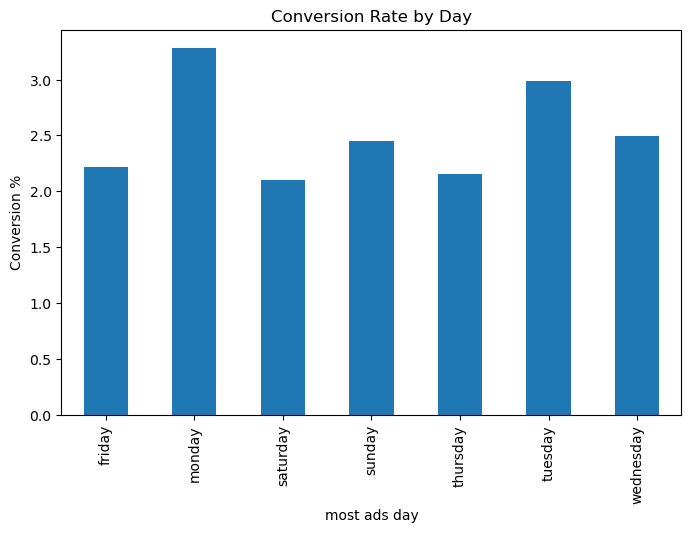

In [116]:
day_conversion = df.groupby(
    "most ads day"
)["converted"].mean() * 100

day_conversion.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Conversion %")
plt.title("Conversion Rate by Day")

plt.show()

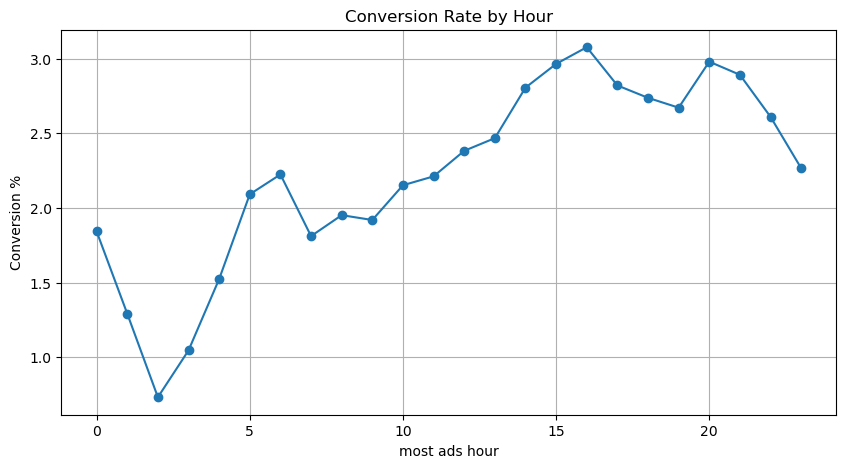

In [117]:
hour_conversion = df.groupby(
    "most ads hour"
)["converted"].mean() * 100

hour_conversion.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.ylabel("Conversion %")
plt.title("Conversion Rate by Hour")

plt.grid(True)

plt.show()

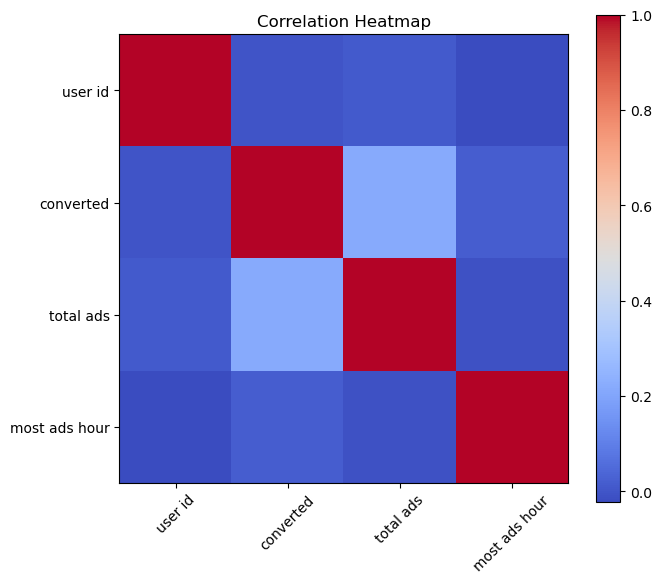

In [118]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

# Key Performance Indicator (KPI)

### How many customers participated in the experiment?

In [119]:
total_customers = df["user id"].nunique()

print("Total Customers:", total_customers)

Total Customers: 588101


In [120]:
converted_customers = df["converted"].sum()

print("Converted Customers:", converted_customers)

Converted Customers: 14843


In [121]:
conversion_rate = round(
    df["converted"].mean() * 100,
    2
)

print("Conversion Rate:", conversion_rate, "%")

Conversion Rate: 2.52 %


In [122]:
average_ads = round(
    df["total ads"].mean(),
    2
)

print("Average Ads:", average_ads)

Average Ads: 24.82


In [123]:
ads_summary = df.groupby("converted")["total ads"].mean()

ads_summary

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

In [124]:
campaign_conversion = df.groupby("test group")["converted"].mean() * 100

campaign_conversion.round(2)

test group
ad     2.55
psa    1.79
Name: converted, dtype: float64

In [125]:
best_day = df.groupby(
    "most ads day"
)["converted"].mean() * 100

best_day.sort_values(
    ascending=False
)

most ads day
monday       3.281155
tuesday      2.984034
wednesday    2.494191
sunday       2.447565
friday       2.221190
thursday     2.157094
saturday     2.105070
Name: converted, dtype: float64

In [126]:
best_hour = df.groupby(
    "most ads hour"
)["converted"].mean() * 100

best_hour.sort_values(
    ascending=False
)

most ads hour
16    3.077169
20    2.980327
15    2.965334
21    2.892314
17    2.820967
14    2.806257
18    2.737988
19    2.671982
22    2.610472
13    2.467737
12    2.382765
23    2.266191
6     2.224371
11    2.211643
10    2.152084
5     2.091503
8     1.951552
9     1.919107
0     1.842486
7     1.811085
4     1.523546
1     1.291129
3     1.045166
2     0.731296
Name: converted, dtype: float64

## We'll define high-value customers as the top 10% of users by advertisement exposure (total ads), since revenue data is unavailable.

In [129]:
# Top 10% customers based on total ads
threshold = df["total ads"].quantile(0.90)

high_value = df[df["total ads"] >= threshold]

high_value.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,monday,20
1,1119715,ad,False,93,tuesday,22
3,1435133,ad,False,355,tuesday,10
4,1015700,ad,False,276,friday,14
5,1137664,ad,False,734,saturday,10


In [130]:
print("High Value Customers:", high_value.shape[0])

High Value Customers: 58884


In [131]:
threshold = df["total ads"].quantile(0.10)

low_value = df[df["total ads"] <= threshold]

low_value.head()

,user id,test group,converted,total ads,most ads day,most ads hour
190,1056345,ad,False,1,tuesday,19
215,903660,psa,False,1,tuesday,19
258,904323,psa,False,2,tuesday,19
267,910192,psa,False,1,tuesday,19
271,1035169,ad,False,1,tuesday,19


In [133]:
inactive = df[df["converted"] == False]

inactive.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,monday,20
1,1119715,ad,False,93,tuesday,22
2,1144181,ad,False,21,tuesday,18
3,1435133,ad,False,355,tuesday,10
4,1015700,ad,False,276,friday,14


In [134]:
threshold = df["total ads"].quantile(0.95)

power_users = df[df["total ads"] >= threshold]

power_users.head()

,user id,test group,converted,total ads,most ads day,most ads hour
0,1069124,ad,False,130,monday,20
1,1119715,ad,False,93,tuesday,22
3,1435133,ad,False,355,tuesday,10
4,1015700,ad,False,276,friday,14
5,1137664,ad,False,734,saturday,10


In [135]:
print("Power Users:", len(power_users))

Power Users: 29496


# Analyze Campaign Performance

In [136]:
campaign_summary = df.groupby("test group").agg({
    "user id": "count",
    "converted": "sum",
    "total ads": "mean"
}).rename(columns={
    "user id": "Total Users",
    "converted": "Conversions",
    "total ads": "Average Ads"
})

campaign_summary["Conversion Rate (%)"] = (
    campaign_summary["Conversions"] /
    campaign_summary["Total Users"]
) * 100

campaign_summary.round(2)

,Total Users,Conversions,Average Ads,Conversion Rate (%)
test group,,,,
ad,564577,14423,24.82,2.55
psa,23524,420,24.76,1.79


In [138]:
funnel = pd.DataFrame({
    "Stage": [
        "Total Users",
        "Converted Users"
    ],
    "Count": [
        len(df),
        df["converted"].sum()
    ]
})

funnel

,Stage,Count
0,Total Users,588101
1,Converted Users,14843


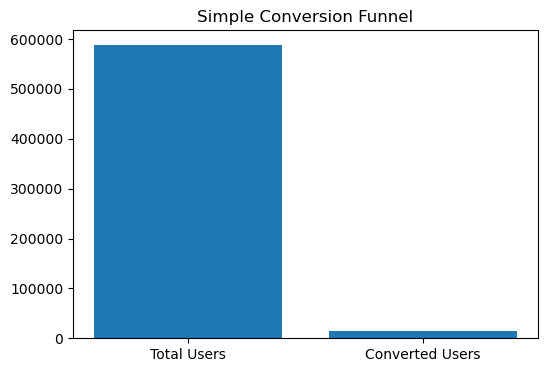

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    funnel["Stage"],
    funnel["Count"]
)

plt.title("Simple Conversion Funnel")

plt.show()

In [140]:
campaign_summary.sort_values(
    "Conversion Rate (%)",
    ascending=False
)

,Total Users,Conversions,Average Ads,Conversion Rate (%)
test group,,,,
ad,564577,14423,24.823365,2.554656
psa,23524,420,24.761138,1.785411


In [141]:
campaign_summary.sort_values(
    "Conversion Rate (%)"
)

,Total Users,Conversions,Average Ads,Conversion Rate (%)
test group,,,,
psa,23524,420,24.761138,1.785411
ad,564577,14423,24.823365,2.554656


## Although calendar dates are unavailable, we can analyze day-of-week and hour-of-day patterns.

In [142]:
day_conversion = (
    df.groupby("most ads day")["converted"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

day_conversion

most ads day
monday       3.281155
tuesday      2.984034
wednesday    2.494191
sunday       2.447565
friday       2.221190
thursday     2.157094
saturday     2.105070
Name: converted, dtype: float64

In [143]:
hour_conversion = (
    df.groupby("most ads hour")["converted"]
      .mean()
      .sort_values(ascending=False)
      * 100
)

hour_conversion

most ads hour
16    3.077169
20    2.980327
15    2.965334
21    2.892314
17    2.820967
14    2.806257
18    2.737988
19    2.671982
22    2.610472
13    2.467737
12    2.382765
23    2.266191
6     2.224371
11    2.211643
10    2.152084
5     2.091503
8     1.951552
9     1.919107
0     1.842486
7     1.811085
4     1.523546
1     1.291129
3     1.045166
2     0.731296
Name: converted, dtype: float64

# A/B Test Analysis

In [144]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

In [145]:
print(df["test group"].unique())

['ad' 'psa']


## Compare the performance of the Control and Treatment groups.

In [146]:
comparison = df.groupby("test group").agg({
    "converted": ["mean", "sum", "count"],
    "total ads": ["mean", "median", "std"]
})

comparison

converted                 total ads                  
                mean    sum   count       mean median        std
test group                                                      
ad          0.025547  14423  564577  24.823365   13.0  43.750456
psa         0.017854    420   23524  24.761138   12.0  42.860720

In [147]:
comparison.columns = [
    "Conversion Rate",
    "Conversions",
    "Users",
    "Average Ads",
    "Median Ads",
    "Std Ads"
]

comparison

,Conversion Rate,Conversions,Users,Average Ads,Median Ads,Std Ads
test group,,,,,,
ad,0.025547,14423,564577,24.823365,13.0,43.750456
psa,0.017854,420,23524,24.761138,12.0,42.860720


In [148]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(
    df["test group"],
    df["converted"]
)

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 54.005823883685245
P-value: 1.9989623063390075e-13


In [149]:
from statsmodels.stats.proportion import proportions_ztest

success = df.groupby("test group")["converted"].sum().values
total = df.groupby("test group")["converted"].count().values

z_stat, p_value = proportions_ztest(success, total)

print("Z Statistic:", z_stat)
print("P-value:", p_value)

Z Statistic: 7.3700781265454145
P-value: 1.7052807161559727e-13


# Step 5 — Check Statistical Assumptions
Business Question

Are the assumptions satisfied?

In [150]:
df["user id"].is_unique

True

In [151]:
df["test group"].value_counts()

test group
ad     564577
psa     23524
Name: count, dtype: int64

# Step 6 — Calculate Business Metrics
A. Absolute Improvement

In [152]:
conversion = (
    df.groupby("test group")["converted"]
      .mean()
      * 100
)

absolute_improvement = (
    conversion["ad"] -
    conversion["psa"]
)

absolute_improvement

np.float64(0.7692453192201518)

In [153]:
lift = (
    absolute_improvement /
    conversion["psa"]
) * 100

lift

np.float64(43.085064022225836)

In [154]:
import numpy as np

p1 = conversion["ad"] / 100
p2 = conversion["psa"] / 100

cohen_h = (
    2*np.arcsin(np.sqrt(p1))
    -
    2*np.arcsin(np.sqrt(p2))
)

cohen_h

np.float64(0.053002578606030915)

In [155]:
from statsmodels.stats.proportion import confint_proportions_2indep

success = df.groupby("test group")["converted"].sum().values
total = df.groupby("test group")["converted"].count().values

low, high = confint_proportions_2indep(
    success[0], total[0],
    success[1], total[1]
)

print("95% CI:", low, high)

95% CI: 0.005873422353060636 0.009360028811460754


In [156]:
from statsmodels.stats.power import NormalIndPower

analysis = NormalIndPower()

power = analysis.solve_power(
    effect_size=abs(cohen_h),
    nobs1=total[0],
    ratio=total[1]/total[0],
    alpha=0.05
)

print("Power:", power)

Power: 0.9999999990438161


# Advanced Business Insights

In [158]:
conversion_ads = df.groupby("converted")["total ads"].mean()

conversion_ads

converted
False    23.291495
True     83.887759
Name: total ads, dtype: float64

In [161]:
conversion_day = (
    df.groupby("most ads day")["converted"]
      .mean()
      .sort_values() * 100
)

conversion_day

most ads day
saturday     2.105070
thursday     2.157094
friday       2.221190
sunday       2.447565
wednesday    2.494191
tuesday      2.984034
monday       3.281155
Name: converted, dtype: float64

In [162]:
conversion_hour = (
    df.groupby("most ads hour")["converted"]
      .mean()
      .sort_values()
)

conversion_hour

most ads hour
2     0.007313
3     0.010452
1     0.012911
4     0.015235
7     0.018111
0     0.018425
9     0.019191
8     0.019516
5     0.020915
10    0.021521
11    0.022116
6     0.022244
23    0.022662
12    0.023828
13    0.024677
22    0.026105
19    0.026720
18    0.027380
14    0.028063
17    0.028210
21    0.028923
15    0.029653
20    0.029803
16    0.030772
Name: converted, dtype: float64

## Which customers create maximum business value?

In [163]:
top_customers = df.nlargest(
    20,
    "total ads"
)[["user id","total ads","converted"]]

top_customers

,user id,total ads,converted
26742,1184464,2065,False
47005,1637962,1778,True
7187,1209450,1680,True
506,1086307,1632,False
15334,1512157,1491,True
16525,1416565,1414,False
9605,1596993,1398,False
80496,1351117,1391,True
27800,1200489,1354,True
107,1389878,1328,True


In [164]:
campaign_summary.sort_values(
    "Conversion Rate (%)"
)

,Total Users,Conversions,Average Ads,Conversion Rate (%)
test group,,,,
psa,23524,420,24.761138,1.785411
ad,564577,14423,24.823365,2.554656


## Where do users drop in the funnel?

In [165]:
funnel = pd.DataFrame({

"Stage":[

"Users",

"Converted"

],

"Count":[

len(df),

df["converted"].sum()

]

})

funnel

,Stage,Count
0,Users,588101
1,Converted,14843


In [166]:
corr = df.corr(numeric_only=True)

corr

,user id,converted,total ads,most ads hour
user id,1.000000,0.000635,0.012336,-0.023002
converted,0.000635,1.000000,0.217419,0.019674
total ads,0.012336,0.217419,1.000000,-0.010837
most ads hour,-0.023002,0.019674,-0.010837,1.000000


In [167]:
pivot = pd.pivot_table(

df,

values="converted",

index="most ads day",

columns="test group",

aggfunc="mean"

)

pivot

test group,ad,psa
most ads day,,
friday,0.022465,0.016303
monday,0.033241,0.022559
saturday,0.021307,0.013996
sunday,0.024620,0.020595
thursday,0.021637,0.020230
tuesday,0.030440,0.014448
wednesday,0.025356,0.015759


In [168]:
df["ads_per_hour"] = (
df["total ads"] /
(df["most ads hour"]+1)
)

In [169]:
df["weekend"] = df["most ads day"].isin([
"Saturday",
"Sunday"
])

In [170]:
threshold = df["total ads"].quantile(.90)

df["high_exposure"] = (
df["total ads"]>=threshold
)

# Strategic Recommendations

In [171]:
campaign_summary.sort_values(
    "Conversion Rate (%)",
    ascending=False
)

,Total Users,Conversions,Average Ads,Conversion Rate (%)
test group,,,,
ad,564577,14423,24.823365,2.554656
psa,23524,420,24.761138,1.785411


In [172]:
best_day = (
    df.groupby("most ads day")["converted"]
      .mean()
      .sort_values(ascending=False)
)

best_hour = (
    df.groupby("most ads hour")["converted"]
      .mean()
      .sort_values(ascending=False)
)

In [173]:
X = df[
    [
        "total ads",
        "most ads hour"
    ]
]

y = df["converted"]

In [174]:
df["weekend"] = df["most ads day"].isin(
[
"Saturday",
"Sunday"
]
)